In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

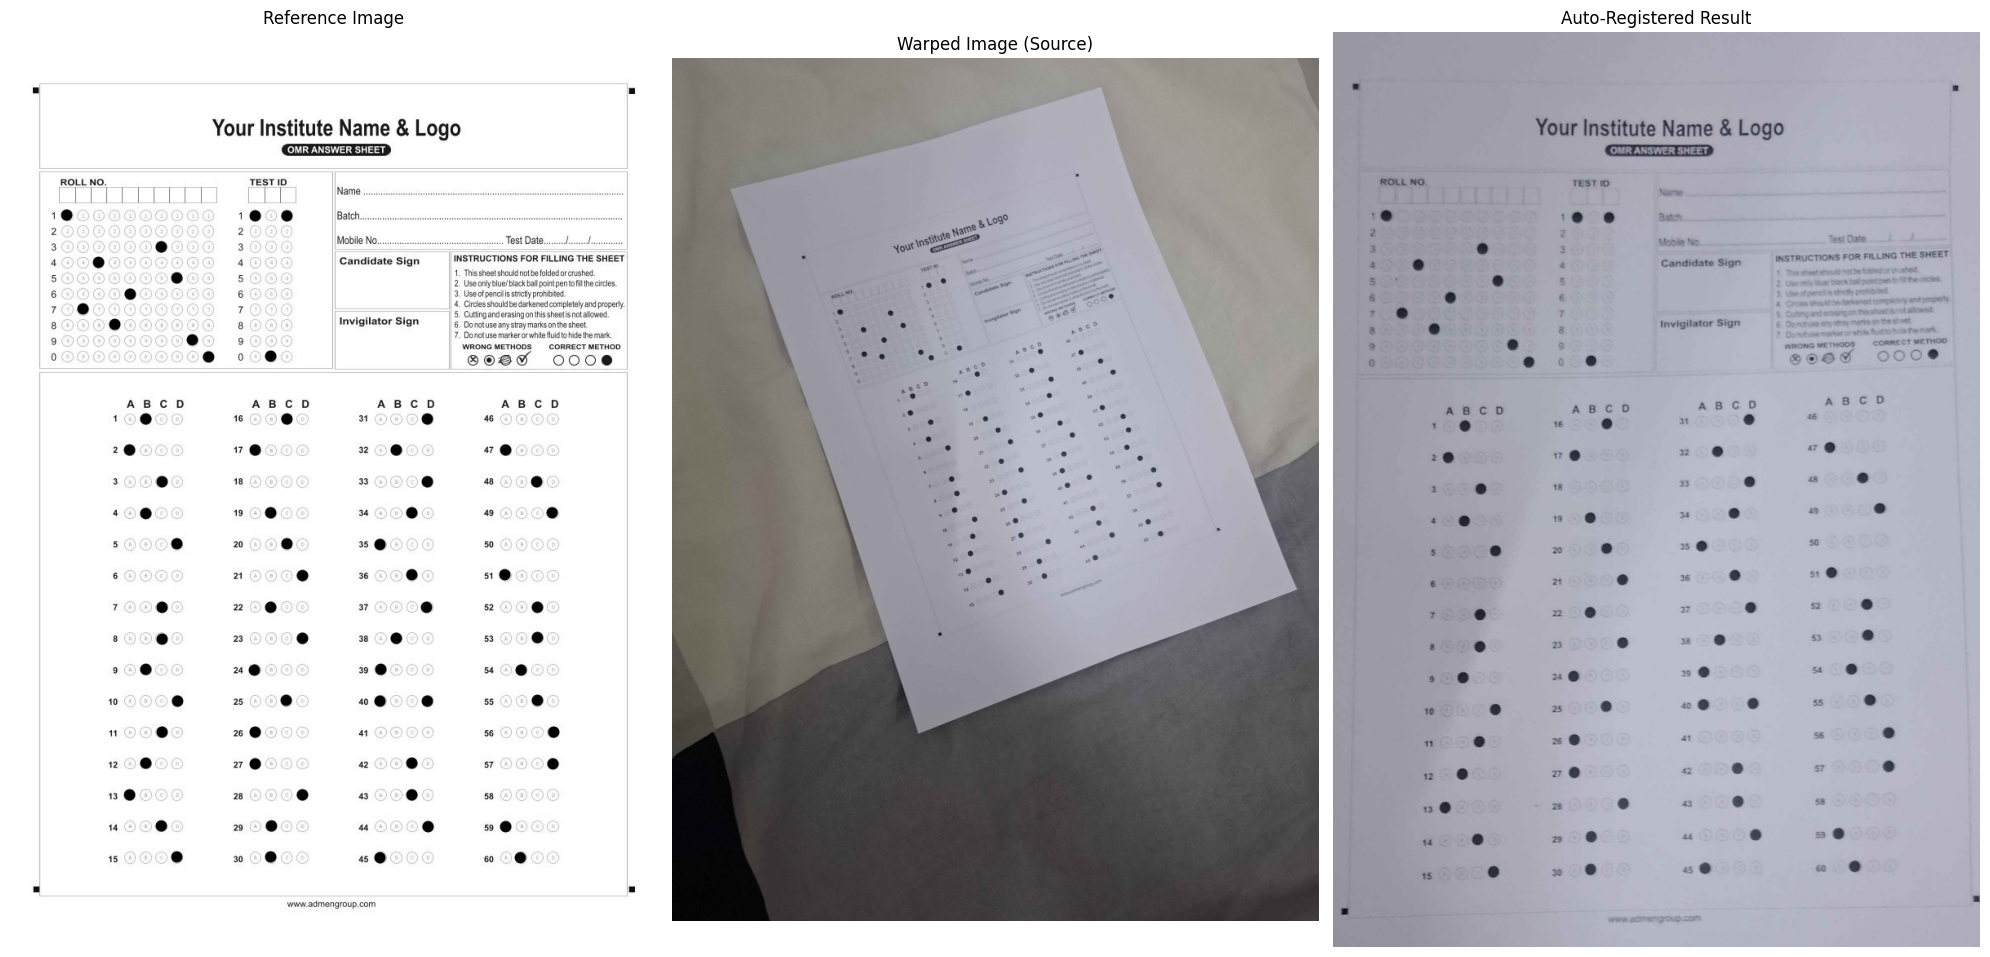

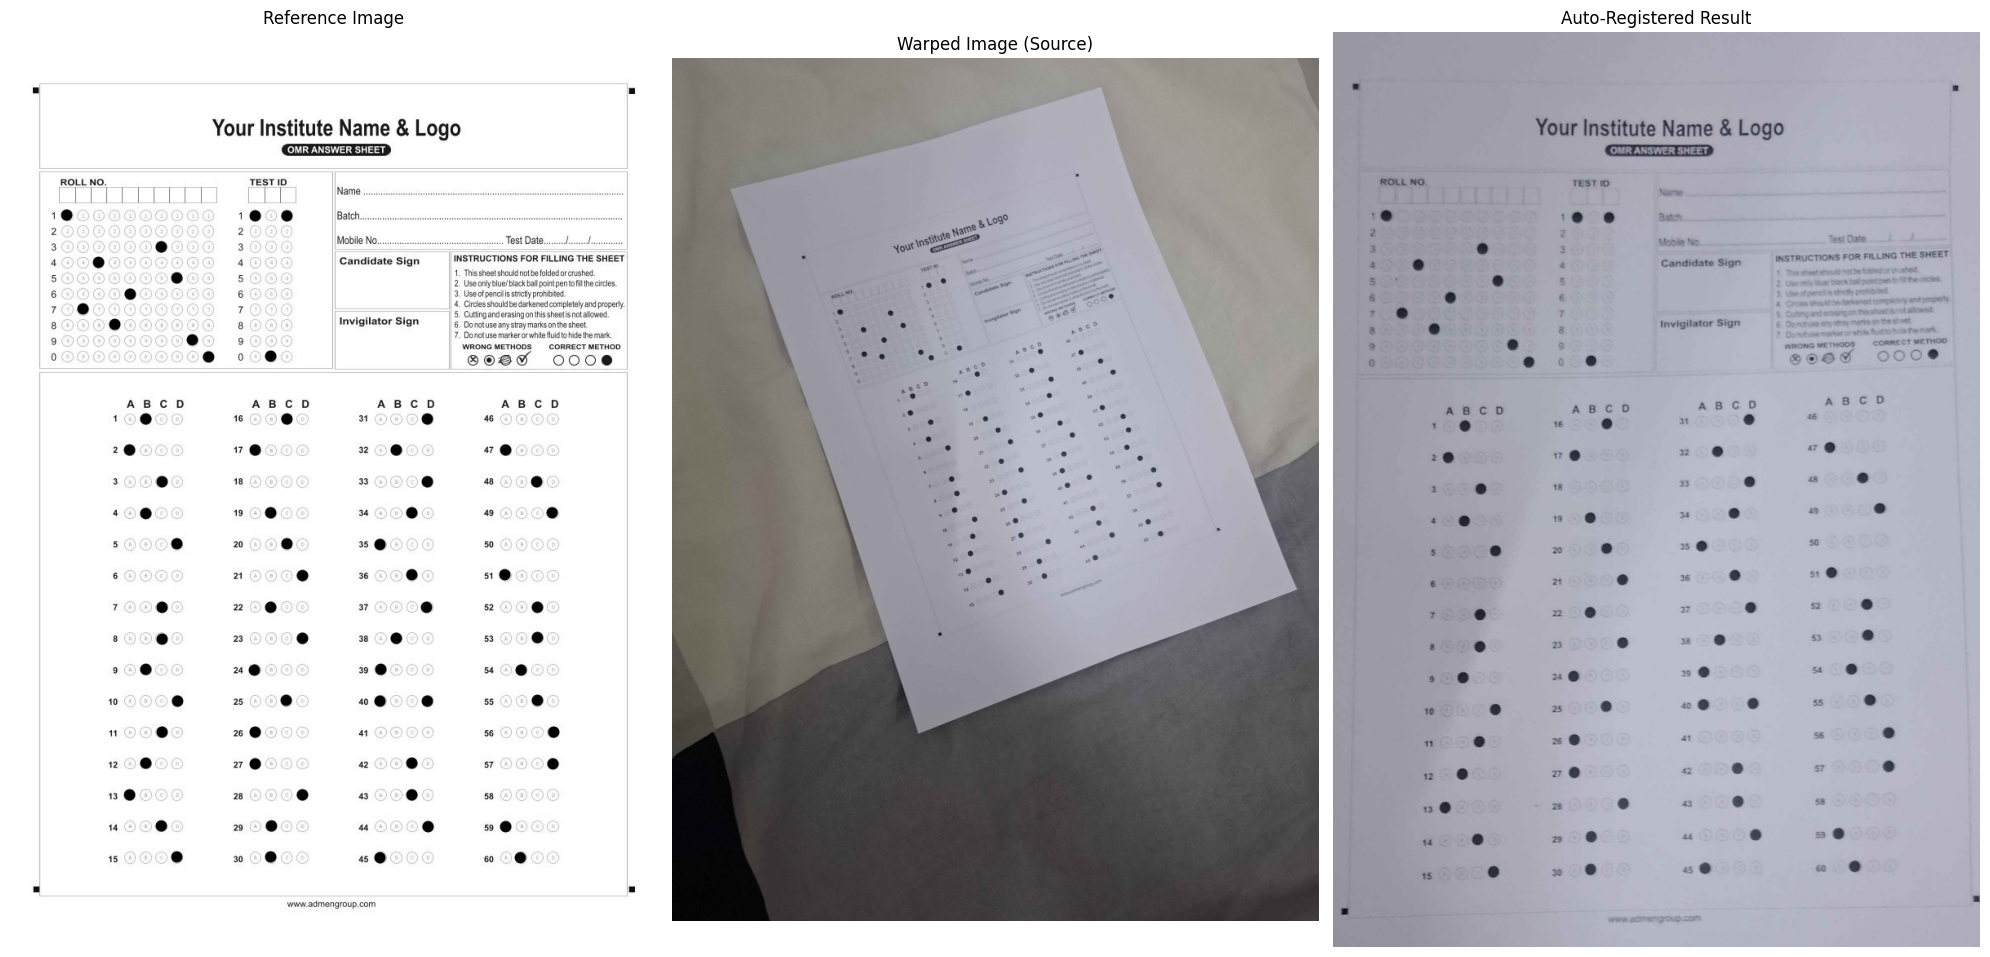

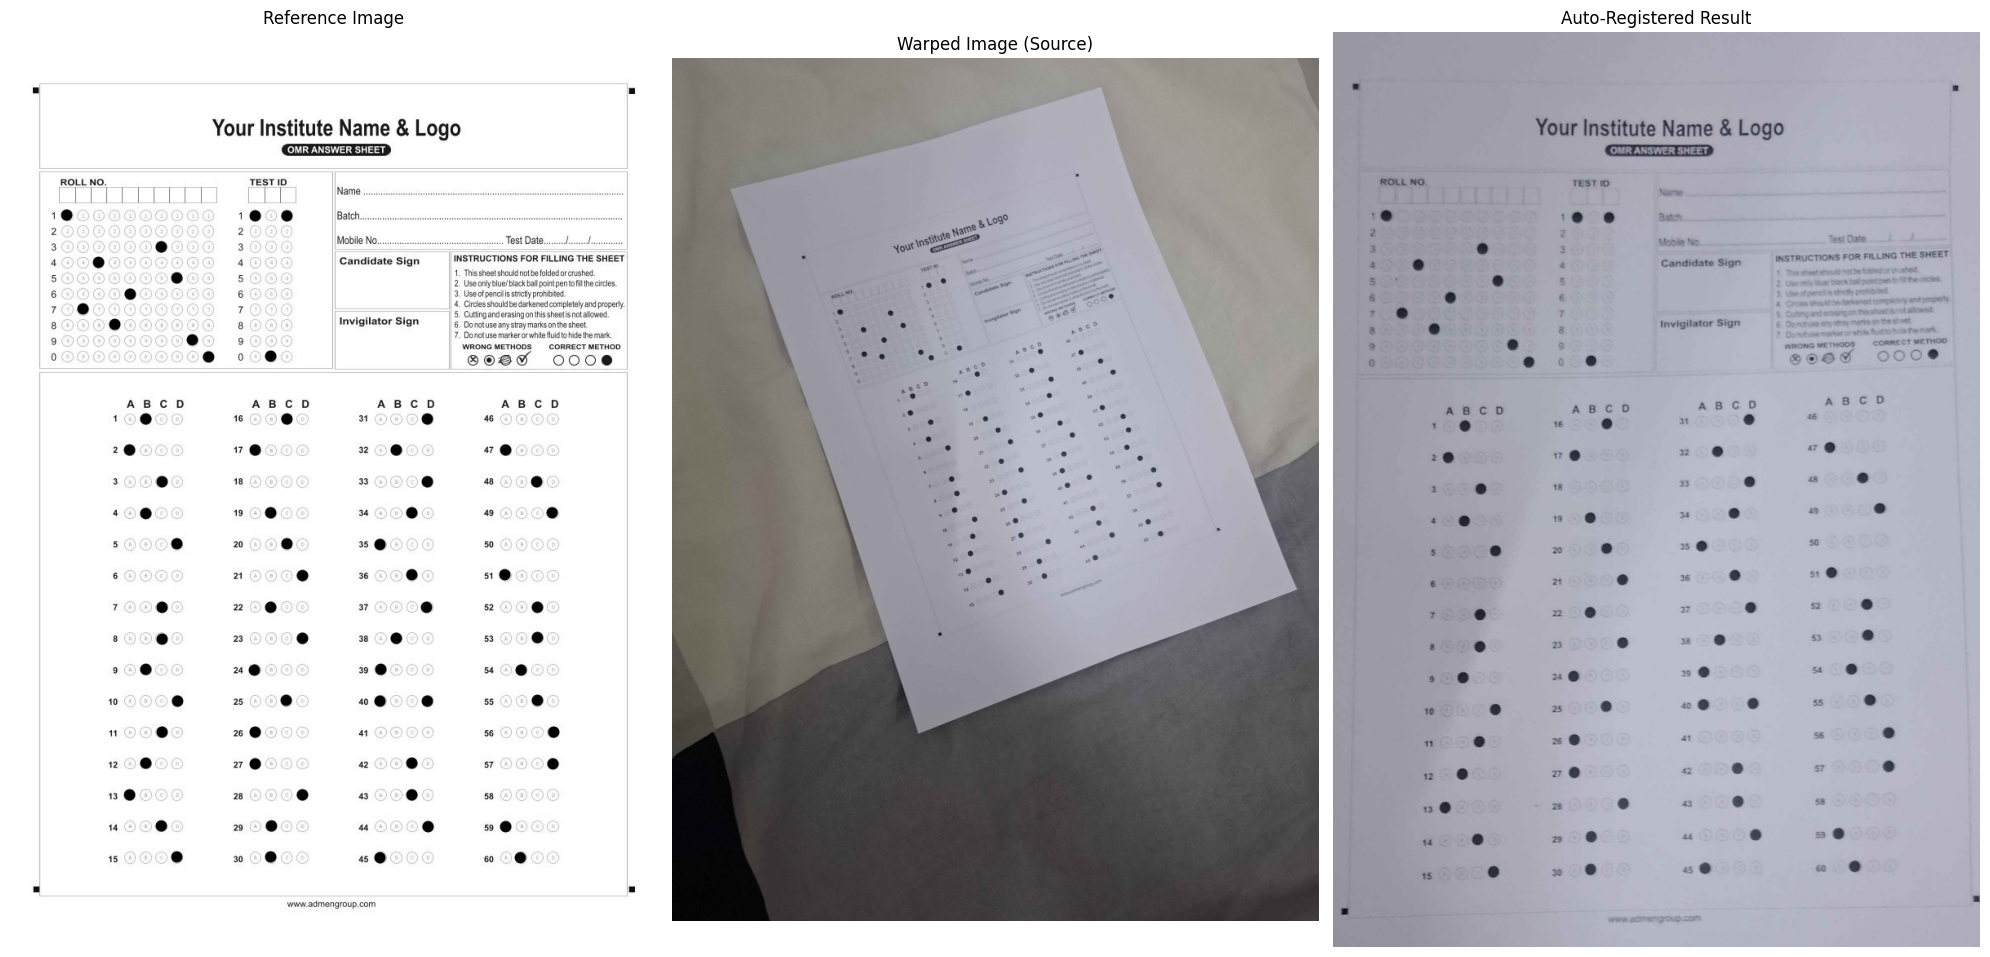

In [ ]:
def auto_register(img_ref_path, img_warped_path):
    # 1. Load images in Grayscale for feature detection
    img1 = cv2.imread(img_ref_path)
    img2 = cv2.imread(img_warped_path)
    
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 2. Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=2000)

    # 3. Find keypoints and descriptors
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    # 4. Match features using Brute-Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    # 5. Extract location of good matches
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)

    for i, match in enumerate(matches):
        points1[i, :] = kp1[match.queryIdx].pt
        points2[i, :] = kp2[match.trainIdx].pt

    # 6. Find Homography using RANSAC (removes bad matches automatically)
    h_matrix, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

    # 7. Warp the image
    height, width, channels = img1.shape
    registered_img = cv2.warpPerspective(img2, h_matrix, (width, height))

    plt.figure(figsize=(20, 10))

    plt.subplot(1, 3, 1)
    plt.title("Reference Image")
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Warped Image (Source)")
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Auto-Registered Result")
    plt.imshow(cv2.cvtColor(registered_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return h_matrix, registered_img

auto_register('../images/image2.png', '../images/image4.png')

registered_image = auto_register('../images/image2.png', '../images/image4.png')

hmatrix, registered_img = auto_register('../images/image2.png', '../images/image4.png')

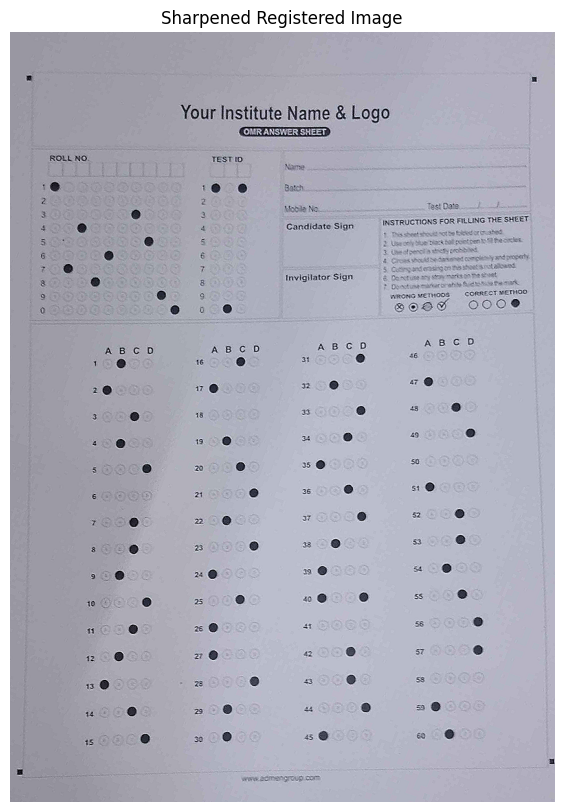

In [3]:
#sharpen the registered image using a simple kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened_img = cv2.filter2D(registered_img, -1, kernel)


plt.figure(figsize=(10, 10))
plt.title("Sharpened Registered Image")
plt.imshow(cv2.cvtColor(sharpened_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [4]:
# save sharpened image in file for later use
cv2.imwrite('../images/registered_image.png', sharpened_img)

True